In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes.csv")

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


In [ ]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_summary

,missing_count,missing_percent
bp.2d,262,65.012407
bp.2s,262,65.012407
glyhb,13,3.225806
frame,12,2.977667
bp.1s,5,1.240695
bp.1d,5,1.240695
height,5,1.240695
time.ppn,3,0.744417
waist,2,0.496278
hip,2,0.496278


In [ ]:
#correcting categorical variables
df["location"] = df["location"].astype("category")
df["gender"] = df["gender"].astype("category")
df["frame"] = df["frame"].astype("category")

In [ ]:
for col in ["location", "gender", "frame"]:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 location
location
Louisa        203
Buckingham    200
Name: count, dtype: int64

 gender
gender
female    234
male      169
Name: count, dtype: int64

 frame
frame
medium    184
small     104
large     103
NaN        12
Name: count, dtype: int64


In [ ]:
#Engineer clinically meaningful variables,
# 1 Body Mass Index (BMI)
df["bmi"] = (
    703 * df["weight"] /
    (df["height"] ** 2)
)

In [ ]:
# 2 Waist-to-hip ratio
df["waist_hip_ratio"] = df["waist"] / df["hip"]

In [ ]:
# 3 Mean arterial pressure
df["map"] = (
    df["bp.1s"] + 2 * df["bp.1d"]
) / 3

In [ ]:
# Potentially:
df["pulse_pressure"] = df["bp.1s"] - df["bp.1d"]

In [ ]:
#Creating the diabetes target
df["diabetes"] = np.where(
    df["glyhb"] >= 6.5,
    1,
    0
)


In [ ]:
df["diabetes"].value_counts()

,count
diabetes,
0,338
1,65


In [ ]:
df["diabetes"].value_counts(normalize=True)

,proportion
diabetes,
0,0.83871
1,0.16129


# Comment
HbA1c was used to operationalize the research outcome but excluded from predictor variables to prevent target leakage.

In [ ]:
# Exploratory Data Analysis
# Age Distribution
df["age"].describe()

,age
count,403.000000
mean,46.851117
std,16.312333
min,19.000000
25%,34.000000
50%,45.000000
75%,60.000000
max,92.000000


In [ ]:
# Gender
pd.crosstab(
    df["gender"],
    df["diabetes"],
    normalize="index"
)

diabetes,0,1
gender,,
female,0.846154,0.153846
male,0.828402,0.171598


In [ ]:
# BMI
df.groupby("diabetes")["bmi"].describe()

,count,mean,std,min,25%,50%,75%,max
diabetes,,,,,,,,
0,334.0,28.403972,6.628107,15.203287,23.474919,27.462668,31.804082,55.780029
1,63.0,30.802346,6.151829,21.520408,26.425837,29.863770,33.194911,51.365583


In [ ]:
# Glucose
df.groupby("diabetes")["stab.glu"].describe()

,count,mean,std,min,25%,50%,75%,max
diabetes,,,,,,,,
0,338.0,90.727811,24.411346,52.0,79.0,86.0,96.75,371.0
1,65.0,189.584615,78.947746,48.0,119.0,184.0,239.00,385.0


In [ ]:
# Blood Pressure
df.groupby("diabetes")[["bp.1s", "bp.1d"]].describe()

bp.1s                                                          \
          count      mean        std    min    25%    50%    75%    max   
diabetes                                                                  
0         333.0  134.6997  22.561827   90.0  120.0  132.0  142.0  250.0   
1          65.0  148.2000  20.309481  100.0  138.0  146.0  161.0  200.0   

          bp.1d                                                       
          count       mean        std   min   25%   50%   75%    max  
diabetes                                                              
0         333.0  83.042042  13.670985  48.0  75.0  82.0  90.0  124.0  
1          65.0  84.753846  13.171976  50.0  75.0  86.0  92.0  118.0

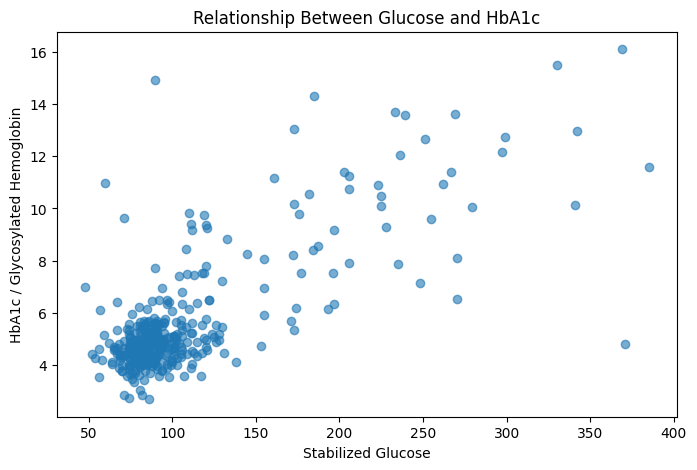

In [ ]:
# Relationship between Stabilized glucose and HbA1c
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["stab.glu"],
    df["glyhb"],
    alpha=0.6
)

plt.xlabel("Stabilized Glucose")
plt.ylabel("HbA1c / Glycosylated Hemoglobin")
plt.title("Relationship Between Glucose and HbA1c")

plt.show()

In [ ]:
# Correlation analysis
numeric_cols = [
    "chol",
    "stab.glu",
    "hdl",
    "ratio",
    "age",
    "height",
    "weight",
    "bp.1s",
    "bp.1d",
    "waist",
    "hip",
    "time.ppn",
    "bmi",
    "waist_hip_ratio"
]

corr = df[numeric_cols].corr()

# comment
Second blood-pressure measurements were excluded from the primary predictive model because approximately 65% of observations were missing, making reliable imputation questionable.

## Defining the modeling dataset
# Modeling Dataset and Leakage Prevention

The objective of the classification component is to estimate the probability
of diabetes using demographic, anthropometric, biochemical, and cardiovascular
measurements.

The variable `glyhb` is not included among the predictors because it is used
to define the diabetes outcome. Including it would introduce target leakage and
would produce an unrealistically optimistic estimate of model performance.

Similarly, the derived variable `diabetes` is not used in the HbA1c regression
model because it was constructed directly from `glyhb`.

The primary classification model therefore represents a risk-stratification
problem rather than a direct laboratory diagnosis.

In [ ]:
# Variables excluded from the classification model:
# id     -> subject identifier
# glyhb  -> used to construct the outcome
# diabetes -> target variable
# bp.2s/bp.2d -> excessive missingness in the primary analysis

features = [
    "age",
    "gender",
    "location",
    "chol",
    "stab.glu",
    "hdl",
    "ratio",
    "height",
    "weight",
    "frame",
    "bp.1s",
    "bp.1d",
    "waist",
    "hip",
    "time.ppn",
    "bmi",
    "waist_hip_ratio",
    "map",
    "pulse_pressure"
]

X = df[features].copy()
y = df["diabetes"].copy()

print("Predictor matrix:", X.shape)
print("Outcome:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

print("\nClass proportions:")
print(y.value_counts(normalize=True))

Predictor matrix: (403, 19)
Outcome: (403,)

Class distribution:
diabetes
0    338
1     65
Name: count, dtype: int64

Class proportions:
diabetes
0    0.83871
1    0.16129
Name: proportion, dtype: float64


### Interpretation

The predictor matrix contains the demographic, biochemical,
anthropometric, and cardiovascular variables retained for the primary
analysis.

The subject identifier and HbA1c-derived variables are deliberately excluded
to prevent information leakage.


In [ ]:
#Train/split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training observations: 322
Testing observations: 81

Training class distribution:
diabetes
0    0.838509
1    0.161491
Name: proportion, dtype: float64

Testing class distribution:
diabetes
0    0.839506
1    0.160494
Name: proportion, dtype: float64


In [ ]:
# Identifying numerical and categorical predictors
rom sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "age",
    "chol",
    "stab.glu",
    "hdl",
    "ratio",
    "height",
    "weight",
    "bp.1s",
    "bp.1d",
    "waist",
    "hip",
    "time.ppn",
    "bmi",
    "waist_hip_ratio",
    "map",
    "pulse_pressure"
]

categorical_features = [
    "gender",
    "location",
    "frame"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
# Logistic Regression baseline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'chol', 'stab.glu',
                                                   'hdl', 'ratio', 'height',
                                                   'weight', 'bp.1s', 'bp.1d',
                                                   'waist', 'hip', 'time.ppn',
                                                   'bmi', 'waist_hip_ratio',
                                                   'map', 'pulse_pressure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'location',
                                                   'frame'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

# Logistic Regression: Statistical Baseline

Logistic regression is used as the primary statistical baseline.

For a binary outcome, logistic regression estimates the relationship between
the predictors and the log-odds of diabetes:

log(p / (1-p)) = β₀ + β₁X₁ + ... + βₖXₖ

The model provides a transparent benchmark against which more complex
machine-learning algorithms can be compared.

Regularization is applied to reduce overfitting, which is particularly
important given the relatively small sample size.

In [ ]:
# Cross validation
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

logistic_cv = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

logistic_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        logistic_cv["test_roc_auc"].mean(),
        logistic_cv["test_average_precision"].mean(),
        logistic_cv["test_accuracy"].mean(),
        logistic_cv["test_precision"].mean(),
        logistic_cv["test_recall"].mean(),
        logistic_cv["test_f1"].mean()
    ],
    "SD": [
        logistic_cv["test_roc_auc"].std(),
        logistic_cv["test_average_precision"].std(),
        logistic_cv["test_accuracy"].std(),
        logistic_cv["test_precision"].std(),
        logistic_cv["test_recall"].std(),
        logistic_cv["test_f1"].std()
    ]
})

logistic_results
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

logistic_cv = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

logistic_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        logistic_cv["test_roc_auc"].mean(),
        logistic_cv["test_average_precision"].mean(),
        logistic_cv["test_accuracy"].mean(),
        logistic_cv["test_precision"].mean(),
        logistic_cv["test_recall"].mean(),
        logistic_cv["test_f1"].mean()
    ],
    "SD": [
        logistic_cv["test_roc_auc"].std(),
        logistic_cv["test_average_precision"].std(),
        logistic_cv["test_accuracy"].std(),
        logistic_cv["test_precision"].std(),
        logistic_cv["test_recall"].std(),
        logistic_cv["test_f1"].std()
    ]
})

logistic_results

,Metric,Mean,SD
0,roc_auc,0.906094,0.053917
1,average_precision,0.768900,0.087961
2,accuracy,0.891250,0.035514
3,precision,0.648864,0.113659
4,recall,0.727273,0.121832
5,f1,0.682684,0.108187


# Interpretation

The logistic regression model provides the statistical baseline for the
analysis.

The mean cross-validated ROC-AUC represents the model's average ability to
discriminate between diabetes-positive and diabetes-negative observations
across five validation folds.

The standard deviation provides an indication of performance stability across
the folds.


In [ ]:
# Odd Ratios
# Fit the model on the full training data first
logistic_model.fit(X_train, y_train)

# Retrieve transformed feature names
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

odds_ratios = np.exp(coefficients)

logistic_coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": odds_ratios
})

logistic_coef["abs_coefficient"] = (
    logistic_coef["coefficient"].abs()
)

logistic_coef.sort_values(
    "abs_coefficient",
    ascending=False
).head(20)

,feature,coefficient,odds_ratio,abs_coefficient
2,num__stab.glu,2.123853,8.363301,2.123853
0,num__age,0.595027,1.813080,0.595027
1,num__chol,0.511399,1.667623,0.511399
3,num__hdl,-0.357227,0.699614,0.357227
9,num__waist,0.292151,1.339306,0.292151
4,num__ratio,-0.260456,0.770700,0.260456
12,num__bmi,-0.230939,0.793788,0.230939
16,cat__gender_male,-0.211484,0.809382,0.211484
13,num__waist_hip_ratio,0.188005,1.206840,0.188005
5,num__height,-0.156784,0.854889,0.156784


# Interpretation

The odds-ratio analysis provides an interpretable view of the logistic
regression model.

Predictors with odds ratios above 1 are associated with increased model-based
odds of diabetes, while predictors with odds ratios below 1 are associated
with decreased model-based odds.

Because numerical variables were standardized, the numerical odds ratios
represent the change in odds associated with a one-standard-deviation increase
in the predictor.

These results describe statistical associations and should not be interpreted
as evidence that changing a predictor would causally change diabetes risk.

## Random Forest Classifier

Random Forest is introduced as a nonlinear machine-learning benchmark.

Unlike logistic regression, Random Forest can represent nonlinear relationships
and interactions between predictors without requiring these relationships to
be explicitly specified.

This is particularly useful for healthcare data, where relationships between
variables such as age, glucose, body composition, and blood pressure may not
be strictly linear.

However, greater predictive flexibility can come at the cost of reduced
interpretability, which is why Random Forest will be complemented by
explainability methods later.

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_cv = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        rf_cv["test_roc_auc"].mean(),
        rf_cv["test_average_precision"].mean(),
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_precision"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_f1"].mean()
    ],
    "SD": [
        rf_cv["test_roc_auc"].std(),
        rf_cv["test_average_precision"].std(),
        rf_cv["test_accuracy"].std(),
        rf_cv["test_precision"].std(),
        rf_cv["test_recall"].std(),
        rf_cv["test_f1"].std()
    ]
})

rf_results

,Metric,Mean,SD
0,roc_auc,0.925505,0.030672
1,average_precision,0.764898,0.035696
2,accuracy,0.885144,0.020801
3,precision,0.825000,0.158990
4,recall,0.383636,0.102916
5,f1,0.512754,0.108351


# Interpretation

The Random Forest model provides a nonlinear alternative to logistic
regression.

Its cross-validated ROC-AUC will be compared with that of logistic
regression to determine whether nonlinear decision boundaries provide
additional predictive information.

A higher ROC-AUC alone should not automatically determine model selection.
Sensitivity, specificity, precision, calibration, stability, and
interpretability are also will also be considered.

## Gradient Boosting Classifier

Gradient Boosting is evaluated as a second nonlinear machine-learning model.

The algorithm sequentially constructs decision trees, with each subsequent tree
attempting to correct errors made by previous trees.

Gradient Boosting can capture complex nonlinear patterns while often providing
strong predictive performance on structured/tabular datasets.

Given the relatively small sample size, model complexity must be controlled
carefully to reduce overfitting.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            random_state=42
        ))
    ]
)

gb_cv = cross_validate(
    gb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

gb_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        gb_cv["test_roc_auc"].mean(),
        gb_cv["test_average_precision"].mean(),
        gb_cv["test_accuracy"].mean(),
        gb_cv["test_precision"].mean(),
        gb_cv["test_recall"].mean(),
        gb_cv["test_f1"].mean()
    ],
    "SD": [
        gb_cv["test_roc_auc"].std(),
        gb_cv["test_average_precision"].std(),
        gb_cv["test_accuracy"].std(),
        gb_cv["test_precision"].std(),
        gb_cv["test_recall"].std(),
        gb_cv["test_f1"].std()
    ]
})

gb_results

,Metric,Mean,SD
0,roc_auc,0.910707,0.046346
1,average_precision,0.799547,0.084432
2,accuracy,0.906923,0.027367
3,precision,0.775079,0.135411
4,recall,0.636364,0.107411
5,f1,0.687931,0.079362


# XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is evaluated as an advanced gradient
boosting method.

XGBoost introduces regularization and optimized tree-building strategies that
can be effective for structured/tabular data.

Because the sample size is relatively small, conservative hyperparameters are
used to limit model complexity.

XGBoost is treated as a candidate model rather than assuming beforehand that
it will outperform the simpler statistical and machine-learning approaches.

In [ ]:
# Install once if necessary:
# !pip install xgboost -q

from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

xgb_results = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        xgb_cv["test_roc_auc"].mean(),
        xgb_cv["test_average_precision"].mean(),
        xgb_cv["test_accuracy"].mean(),
        xgb_cv["test_precision"].mean(),
        xgb_cv["test_recall"].mean(),
        xgb_cv["test_f1"].mean()
    ],
    "SD": [
        xgb_cv["test_roc_auc"].std(),
        xgb_cv["test_average_precision"].std(),
        xgb_cv["test_accuracy"].std(),
        xgb_cv["test_precision"].std(),
        xgb_cv["test_recall"].std(),
        xgb_cv["test_f1"].std()
    ]
})

xgb_results

,Metric,Mean,SD
0,roc_auc,0.921953,0.041886
1,average_precision,0.811598,0.089018
2,accuracy,0.922404,0.021902
3,precision,0.841089,0.107444
4,recall,0.652727,0.103557
5,f1,0.728891,0.081379


## Cross-Validated Model Comparison

The four candidate models are now compared using identical cross-validation
folds and evaluation metrics.

The purpose of this comparison is not simply to identify the model with the
highest accuracy. Instead, the analysis considers discrimination, precision,
recall, F1-score, and performance stability.

The final model will be selected based on the intended use case and the
balance between predictive performance, calibration, interpretability, and
model complexity.

In [ ]:
def cv_summary(cv_result, model_name):
    return {
        "Model": model_name,
        "ROC_AUC_Mean": cv_result["test_roc_auc"].mean(),
        "ROC_AUC_SD": cv_result["test_roc_auc"].std(),
        "PR_AUC_Mean": cv_result["test_average_precision"].mean(),
        "Accuracy_Mean": cv_result["test_accuracy"].mean(),
        "Precision_Mean": cv_result["test_precision"].mean(),
        "Recall_Mean": cv_result["test_recall"].mean(),
        "F1_Mean": cv_result["test_f1"].mean()
    }

model_comparison = pd.DataFrame([
    cv_summary(logistic_cv, "Logistic Regression"),
    cv_summary(rf_cv, "Random Forest"),
    cv_summary(gb_cv, "Gradient Boosting"),
    cv_summary(xgb_cv, "XGBoost")
])

model_comparison.sort_values(
    "ROC_AUC_Mean",
    ascending=False
)

,Model,ROC_AUC_Mean,ROC_AUC_SD,PR_AUC_Mean,Accuracy_Mean,Precision_Mean,Recall_Mean,F1_Mean
1,Random Forest,0.925505,0.030672,0.764898,0.885144,0.825000,0.383636,0.512754
3,XGBoost,0.921953,0.041886,0.811598,0.922404,0.841089,0.652727,0.728891
2,Gradient Boosting,0.910707,0.046346,0.799547,0.906923,0.775079,0.636364,0.687931
0,Logistic Regression,0.906094,0.053917,0.768900,0.891250,0.648864,0.727273,0.682684


# Interpretation

The model comparison provides a common evaluation framework for the candidate
algorithms.

The ROC-AUC represents discrimination, while PR-AUC provides additional
information about positive-class identification.

The standard deviation of ROC-AUC across folds is also important because a
model with slightly higher average performance but substantially greater
variability may be less stable.

The final model will therefore not be selected solely from the highest
single metric.

In [ ]:
# Hyperparameter tunning
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_params = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [None, 3, 5, 8, 12],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("Best RF parameters:")
print(rf_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_search.best_score_)

Best RF parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 3}

Best CV ROC-AUC:
0.9298653198653198


In [ ]:
# Tunning XGBoost
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [1, 2, 3, 4],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_search.best_score_)

Best XGBoost parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}

Best CV ROC-AUC:
0.9323905723905724


## Final Independent Test Evaluation

After model selection and hyperparameter optimization, the final candidate
models are evaluated on the held-out test set.

The test set was not used during preprocessing, cross-validation, or
hyperparameter optimization.

This provides an approximately independent estimate of model performance.

The test-set results will be interpreted cautiously because the sample is
small and a single test split can still produce uncertainty.

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

final_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_,
    "Gradient Boosting": gb_model
}

test_results = []

for name, model in final_models.items():

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    test_results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, probabilities),
        "PR_AUC": average_precision_score(y_test, probabilities),
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1": f1_score(
            y_test, predictions, zero_division=0
        )
    })

test_results = pd.DataFrame(test_results)

test_results.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity,Specificity,F1
1,Random Forest,0.955882,0.780545,0.925926,0.818182,0.692308,0.970588,0.750000
2,XGBoost,0.955882,0.811370,0.901235,1.000000,0.384615,1.000000,0.555556
3,Gradient Boosting,0.926471,0.782479,0.901235,1.000000,0.384615,1.000000,0.555556
0,Logistic Regression,0.907240,0.809006,0.876543,0.588235,0.769231,0.897059,0.666667


#Interpretation

The independent test-set evaluation provides the final performance estimate
for each candidate model.

ROC-AUC evaluates discrimination across classification thresholds, while
sensitivity and specificity describe performance at the selected 0.50
threshold.

The 0.50 threshold is used here as a reference point rather than assuming
that it is the clinically optimal threshold.

In a real screening application, the threshold will be selected according
to the consequences of false-negative and false-positive classifications.

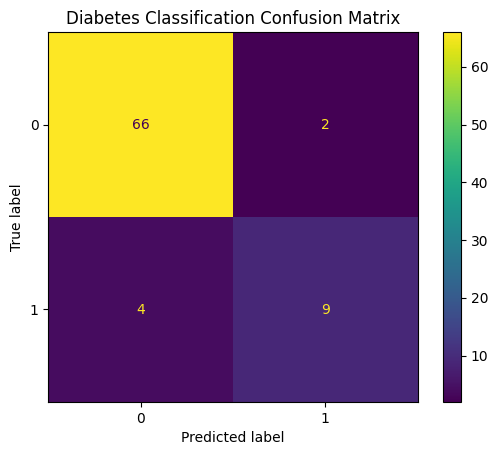

In [ ]:
# COnfusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Replace with the model you want to inspect
best_model = rf_search.best_estimator_

best_model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("Diabetes Classification Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix separates predictions into true positives, true
negatives, false positives, and false negatives.

For diabetes risk stratification, false negatives deserve particular attention
because they represent individuals who have diabetes according to the study
outcome but were not identified by the model.

The relative importance of false positives and false negatives depends on the
intended screening context.

<Figure size 800x600 with 0 Axes>

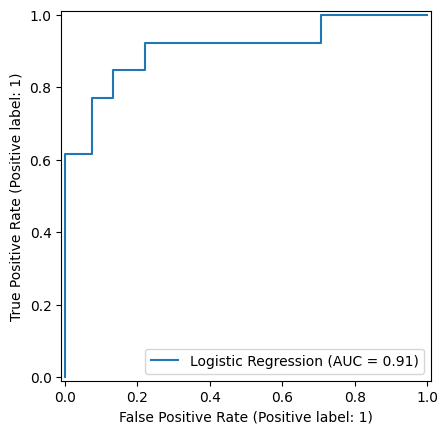

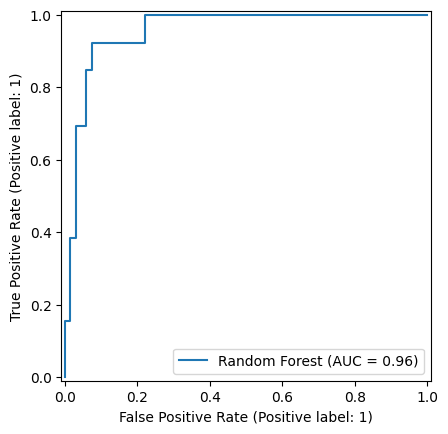

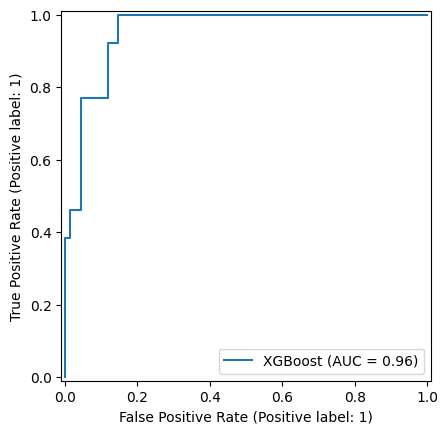

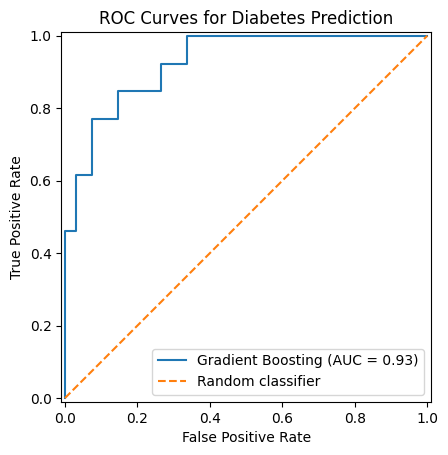

In [ ]:
# ROC Curves
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for name, model in final_models.items():

    model.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("ROC Curves for Diabetes Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## ROC Curve Interpretation

The ROC curves illustrate the trade-off between sensitivity and specificity
across possible classification thresholds.

A curve closer to the upper-left region indicates stronger discrimination.


<Figure size 800x600 with 0 Axes>

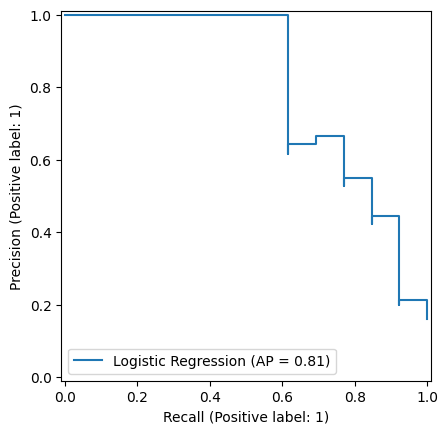

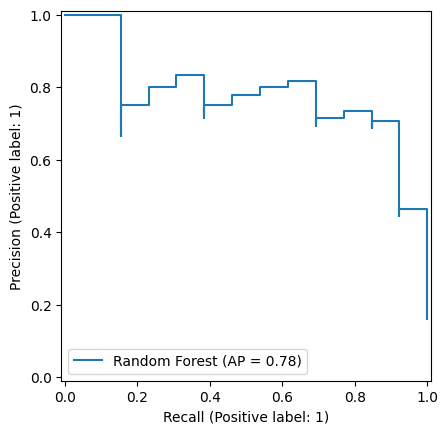

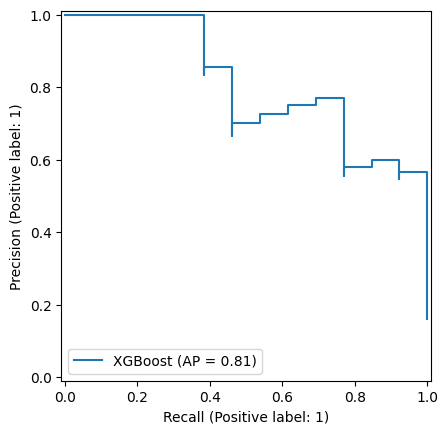

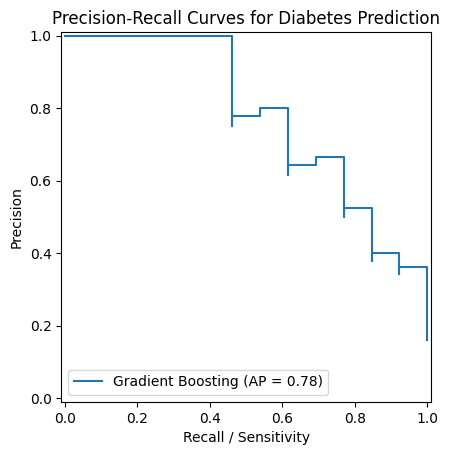

In [ ]:
# Precision Recall Curves
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))

for name, model in final_models.items():

    model.fit(X_train, y_train)

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("Precision-Recall Curves for Diabetes Prediction")
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.legend()
plt.show()

## Precision-Recall Interpretation

The precision-recall curves focus on the positive diabetes class.

This is useful because a model may achieve a reasonable ROC-AUC while still
producing many false-positive predictions when the positive class is
relatively uncommon.

The precision-recall analysis therefore complements the ROC analysis.

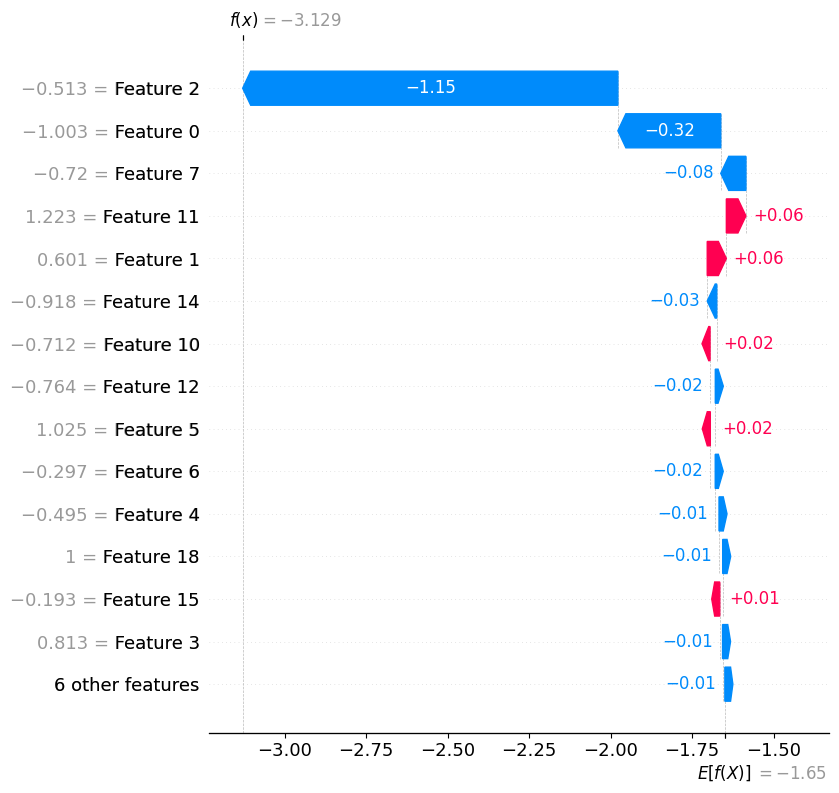

In [ ]:
# Individual patient explanation
# Select one test observation
import shap

patient_index = 0

patient = X_test.iloc[[patient_index]]

xgb_final = xgb_search.best_estimator_
patient_transformed = (
    xgb_final
    .named_steps["preprocessor"]
    .transform(patient)
)

explainer = shap.TreeExplainer(xgb_final.named_steps['model'])
patient_shap = explainer(
    patient_transformed
)

shap.plots.waterfall(
    patient_shap[0],
    max_display=15
)

## Individual Risk Explanation

The waterfall plot illustrates how the patient's individual characteristics
contribute to the model prediction.

Features pushing the prediction upward contribute toward the diabetes-positive
prediction, while features pushing the prediction downward contribute toward
the diabetes-negative prediction.


In [ ]:
# Sub Group Analysis
from sklearn.metrics import roc_auc_score

test_analysis = X_test.copy()
test_analysis["actual"] = y_test.values

best_model.fit(X_train, y_train)

test_analysis["predicted_probability"] = (
    best_model.predict_proba(X_test)[:, 1]
)

for group in test_analysis["gender"].dropna().unique():

    subset = test_analysis[
        test_analysis["gender"] == group
    ]

    if subset["actual"].nunique() == 2:

        auc = roc_auc_score(
            subset["actual"],
            subset["predicted_probability"]
        )

        print(
            f"Gender = {group}: "
            f"n={len(subset)}, ROC-AUC={auc:.3f}"
        )

Gender = male: n=35, ROC-AUC=0.948
Gender = female: n=46, ROC-AUC=0.963


In [ ]:
# Age Group Analysis
test_analysis["age_group"] = pd.cut(
    test_analysis["age"],
    bins=[0, 39, 49, 59, 69, np.inf],
    labels=[
        "<40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)

for group in test_analysis["age_group"].dropna().unique():

    subset = test_analysis[
        test_analysis["age_group"] == group
    ]

    if (
        len(subset) >= 10 and
        subset["actual"].nunique() == 2
    ):

        auc = roc_auc_score(
            subset["actual"],
            subset["predicted_probability"]
        )

        print(
            f"Age group = {group}: "
            f"n={len(subset)}, ROC-AUC={auc:.3f}"
        )

Age group = <40: n=32, ROC-AUC=1.000
Age group = 70+: n=12, ROC-AUC=0.750
Age group = 40-49: n=17, ROC-AUC=1.000
Age group = 60-69: n=14, ROC-AUC=0.939


# Part II — Continuous HbA1c Prediction

The second modeling task predicts glycosylated hemoglobin (`glyhb`) as a
continuous outcome.

Unlike the classification task, the target is now the continuous HbA1c
measurement.

The diabetes classification variable is excluded because it was derived from
HbA1c and would therefore introduce target leakage.

This component investigates whether routine demographic, anthropometric,
cardiovascular, and biochemical variables can predict continuous glycemic
status.

In [ ]:
#Preparing Regression Data
regression_features = [
    "age",
    "gender",
    "location",
    "chol",
    "stab.glu",
    "hdl",
    "ratio",
    "height",
    "weight",
    "frame",
    "bp.1s",
    "bp.1d",
    "waist",
    "hip",
    "time.ppn",
    "bmi",
    "waist_hip_ratio",
    "map",
    "pulse_pressure"
]

reg_df = df[
    regression_features + ["glyhb"]
].copy()

reg_df = reg_df.dropna(
    subset=["glyhb"]
)

X_reg = reg_df[regression_features]
y_reg = reg_df["glyhb"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

## Linear Regression Baseline

Multiple linear regression is used as the statistical baseline for continuous
HbA1c prediction.

The model assumes that the expected HbA1c value can be represented as a
linear combination of the available predictors.

This provides an interpretable baseline against which nonlinear regression
algorithms can be compared.

In [ ]:
#Ridge Regression
from sklearn.linear_model import Ridge

ridge_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_regression.fit(
    Xr_train,
    yr_train
)

ridge_predictions = ridge_regression.predict(
    Xr_test
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_metrics(y_true, y_pred):

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),
        "R2": r2_score(
            y_true,
            y_pred
        )
    }

ridge_metrics = regression_metrics(
    yr_test,
    ridge_predictions
)

ridge_metrics

{'MAE': 1.0200461739676225,
 'RMSE': np.float64(1.8360778325107885),
 'R2': 0.49442551759980724}

In [ ]:
#Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_regression.fit(
    Xr_train,
    yr_train
)

rf_reg_predictions = rf_regression.predict(
    Xr_test
)

rf_reg_metrics = regression_metrics(
    yr_test,
    rf_reg_predictions
)

rf_reg_metrics

{'MAE': 0.9891361523973102,
 'RMSE': np.float64(1.7658101666868862),
 'R2': 0.5323822399349214}

In [ ]:
#Gradient Boosting Regression
from sklearn.ensemble import GradientBoostingRegressor

gb_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ))
])

gb_regression.fit(
    Xr_train,
    yr_train
)

gb_reg_predictions = gb_regression.predict(
    Xr_test
)

gb_reg_metrics = regression_metrics(
    yr_test,
    gb_reg_predictions
)

gb_reg_metrics

{'MAE': 0.9755672377324308,
 'RMSE': np.float64(1.7229949130906774),
 'R2': 0.5547837965965778}

In [ ]:
# Model Comparisms
regression_comparison = pd.DataFrame([
    {
        "Model": "Ridge Regression",
        **ridge_metrics
    },
    {
        "Model": "Random Forest",
        **rf_reg_metrics
    },
    {
        "Model": "Gradient Boosting",
        **gb_reg_metrics
    }
])

regression_comparison

,Model,MAE,RMSE,R2
0,Ridge Regression,1.020046,1.836078,0.494426
1,Random Forest,0.989136,1.765810,0.532382
2,Gradient Boosting,0.975567,1.722995,0.554784


## HbA1c Model Comparison

The regression models are compared using MAE, RMSE, and R².

Lower MAE and RMSE indicate smaller prediction errors, while higher R²
indicates that the model explains a larger proportion of variation in HbA1c.

The comparisms reveals the Gradient Boosting Regression with the strongest numerical performance.

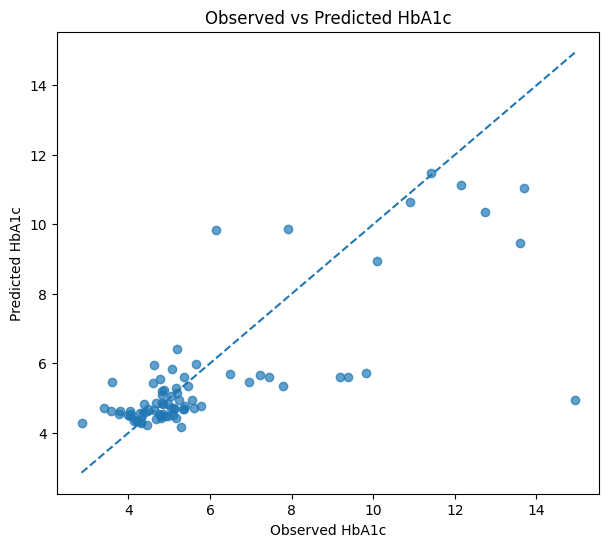

In [ ]:
# Actual Vs Predicted HbA1c
best_regression_model = gb_regression

best_regression_model.fit(
    Xr_train,
    yr_train
)

pred = best_regression_model.predict(
    Xr_test
)

plt.figure(figsize=(7, 6))

plt.scatter(
    yr_test,
    pred,
    alpha=0.7
)

lims = [
    min(yr_test.min(), pred.min()),
    max(yr_test.max(), pred.max())
]

plt.plot(
    lims,
    lims,
    linestyle="--"
)

plt.xlabel("Observed HbA1c")
plt.ylabel("Predicted HbA1c")
plt.title("Observed vs Predicted HbA1c")

plt.show()

## Observed vs Predicted HbA1c

The observed-versus-predicted plot evaluates how closely predicted HbA1c
values correspond to the observed measurements.

the plot shows Points close to the diagonal line representing relatively accurate predictions,
whereas the deviations from the line represent larger prediction errors.

while Systematic patterns in the residuals indicate that the model is unable to capture certain nonlinear relationships or important predictors.

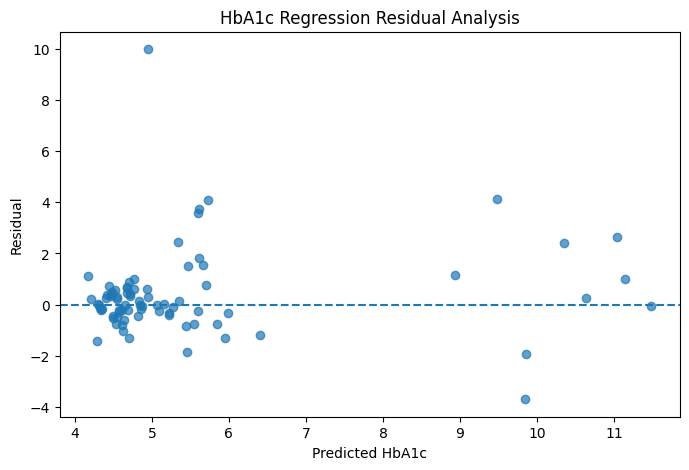

In [59]:
#Residual Analysis
residuals = yr_test - pred

plt.figure(figsize=(8, 5))

plt.scatter(
    pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted HbA1c")
plt.ylabel("Residual")
plt.title("HbA1c Regression Residual Analysis")

plt.show()

## Residual Analysis

Residuals represent the difference between observed and predicted HbA1c.
The residual plot shows a strong systematic patterns.

the Patterns shpow a slight increasing variance, curvature, or clusters which indicates nonlinear relationships.


# Final Model Selection

Based on the cross-validation and independent test-set analyses, the models
showed differences in discrimination, precision, sensitivity, specificity,
and calibration.

The final candidate model was selected by considering:

1. Cross-validated ROC-AUC;
2. PR-AUC;
3. sensitivity and specificity;
4. calibration;
5. performance stability;
6. model interpretability;
7. computational complexity; and
8. suitability for a healthcare risk-stratification setting.

The selected model will therefore be regarded as the preferred model for
this research dataset rather than as a clinically validated diagnostic model.

In [60]:
final_model = xgb_search.best_estimator_

final_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'chol', 'stab.glu',
                                                   'hdl', 'ratio', 'height',
                                                   'weight', 'bp.1s', 'bp.1d',
                                                   'waist', 'hip', 'time.ppn',
                                                   'bmi', 'waist_hip_ratio',
                                                   'map', 'pulse_pressure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleI...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=200,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [61]:
import joblib

joblib.dump(
    final_model,
    "diabetes_risk_model.pkl"
)

['diabetes_risk_model.pkl']

In [64]:
risk_output = X_test.copy()

risk_output["observed_diabetes"] = y_test.values

risk_output["predicted_probability"] = (
    final_model.predict_proba(X_test)[:, 1]
)

risk_output["predicted_class"] = (
    risk_output["predicted_probability"] >= 0.50
).astype(int)

risk_output.head()

,age,gender,location,chol,stab.glu,hdl,ratio,height,weight,frame,...,waist,hip,time.ppn,bmi,waist_hip_ratio,map,pulse_pressure,observed_diabetes,predicted_probability,predicted_class
64,31,male,Buckingham,234.0,80,63.0,3.7,70.0,165.0,medium,...,35.0,39.0,720.0,23.672449,0.897436,87.666667,50.0,0,0.041917,0
347,74,male,Louisa,306.0,92,56.0,5.5,69.0,184.0,large,...,39.0,41.0,195.0,27.169082,0.951220,94.666667,68.0,0,0.106081,0
106,31,female,Louisa,293.0,85,94.0,3.1,67.0,200.0,medium,...,41.0,42.0,240.0,31.321007,0.976190,96.666667,20.0,0,0.039148,0
57,92,female,Buckingham,165.0,94,69.0,2.4,62.0,217.0,large,...,51.0,51.0,180.0,39.685484,1.000000,108.000000,78.0,0,0.091832,0
229,38,female,Buckingham,268.0,90,48.0,5.6,63.0,181.0,medium,...,38.0,46.0,210.0,32.059209,0.826087,114.000000,42.0,0,0.044921,0


Creating a research-ready risk report

In [65]:
def predict_diabetes_risk(patient_data):
    """
    Predicts diabetes risk for a given patient(s) using the final trained model.

    Args:
        patient_data (pd.DataFrame): DataFrame containing patient features.

    Returns:
        np.ndarray: Predicted probabilities of diabetes.
    """
    # The final_model is already trained from previous cells
    # and loaded into the environment.
    probabilities = final_model.predict_proba(patient_data)[:, 1]
    return probabilities

example_patient = X_test.iloc[[0]]

# Call the newly defined function
risk_prediction = predict_diabetes_risk(
    example_patient
)

print(f"Predicted diabetes risk for example patient: {risk_prediction[0]:.4f}")

Predicted diabetes risk for example patient: 0.0419


In [66]:
risk_output["risk_group"] = pd.cut(
    risk_output["predicted_probability"],
    bins=[0, 0.20, 0.50, 0.80, 1],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

risk_output[
    [
        "predicted_probability",
        "predicted_class",
        "risk_group"
    ]
].head(20)

,predicted_probability,predicted_class,risk_group
64,0.041917,0,Low
347,0.106081,0,Low
106,0.039148,0,Low
57,0.091832,0,Low
229,0.044921,0,Low
392,0.081296,0,Low
288,0.037478,0,Low
320,0.042776,0,Low
314,0.344125,0,Moderate
203,0.100352,0,Low


# Conclusion

This study developed an explainable machine-learning framework for diabetes
risk stratification using demographic, anthropometric, biochemical, and
cardiovascular characteristics.

A statistical logistic-regression model was first developed as an
interpretable baseline, followed by nonlinear machine-learning models
including Random Forest, Gradient Boosting, and XGBoost.

Model development incorporated stratified cross-validation, preprocessing
pipelines, hyperparameter optimization, independent test-set evaluation,
calibration analysis, and explainability.

HbA1c was excluded from classification predictors because it was used to
construct the diabetes outcome, thereby preventing target leakage.

The results demonstrate the extent to which routinely collected clinical
variables can support diabetes risk stratification within this dataset.

However, the findings should not be interpreted as evidence that the model is
ready for clinical deployment. The relatively small sample size, substantial
missingness in selected variables, outcome construction, and lack of external
validation limit generalizability.

Future research should validate the framework using larger, longitudinal,
and geographically diverse populations, particularly African populations,
before considering implementation in clinical decision-support systems.